# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Geethan Sundaram

**Date:** 9/3/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np

# Q1.1
print("****************Q1.1****************")

# Load airbnb data
airbnb_hw = pd.read_csv('data/airbnb_hw.csv')

# Check the data types and unique values of the Price variable
print("\nData types: ", airbnb_hw['Price'].dtype)
print("Unique values: ", airbnb_hw['Price'].unique()[:20])

# Check basic stats of the Price variable
print("\nBasic stats: ")
print(airbnb_hw['Price'].describe())

# Check first few rows of the Price variable
print("\nFirst few rows: ")
print(airbnb_hw['Price'].head())

# Check for missing values in the Price variable
print("\nMissing values before: ", airbnb_hw['Price'].isna().sum())

# Clean the 'Price' variable by removing commas and converting to numeric
airbnb_hw['Price_cleaned'] = (airbnb_hw['Price'].str.replace(',', '', regex=False))
airbnb_hw['Price_cleaned'] = pd.to_numeric(airbnb_hw['Price_cleaned'], errors='coerce')

# Check the cleaned Price variable first feq rows
print("\nCleaned Price variable: ")
print(airbnb_hw['Price_cleaned'].head())

# Check the stats and check for missing values in the cleaned Price variable
print("\nCleaned Price variable stats: ")
print(airbnb_hw['Price_cleaned'].describe())
print("\nMissing values after: ", airbnb_hw['Price_cleaned'].isna().sum())

# 

# Q1.2
print("\n\n****************Q1.2****************")

# Load police data
police_data = pd.read_csv('data/mn_police_use_of_force.csv')

# Check data types and unique values of the subject_injury variable
print("\nUnique values: ", police_data['subject_injury'].unique())
print("Value counts: ", police_data['subject_injury'].value_counts(dropna=False))

# Clean the subject_injury  variable by stripping whitespace and converting to string
police_data["subject_injury_cleaned"] = (
    police_data["subject_injury"]
    .astype("string")
    .str.strip()
)

# Clean the subject_injury_cleaned variable by keeping only "Yes" and "No" values and settin others to NaN
police_data["subject_injury_cleaned"] = police_data["subject_injury_cleaned"].where(
    police_data["subject_injury_cleaned"].isin(["Yes", "No"]),
    pd.NA
)

# Missing indicator for subject_injury_cleaned
missing_proportion = police_data["subject_injury_cleaned"].isna().mean()
print("\nProportion missing:", missing_proportion)
print("Percent missing:", missing_proportion * 100)


# Make cross-tabulations
police_data["subject_injury_table"] = (
    police_data["subject_injury_cleaned"].fillna("Missing")
)

print()
print(
    pd.crosstab(
        police_data["force_type"],
        police_data["subject_injury_table"]
    )
)

****************Q1.1****************

Data types:  object
Unique values:  ['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125']

Basic stats: 
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object

First few rows: 
0    145
1     37
2     28
3    199
4    549
Name: Price, dtype: object

Missing values before:  0

Cleaned Price variable: 
0    145
1     37
2     28
3    199
4    549
Name: Price_cleaned, dtype: int64

Cleaned Price variable stats: 
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price_cleaned, dtype: float64

Missing values after:  0


****************Q1.2****************

Unique values:  [nan 'No' 'Yes']
Value counts:  subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Proportion missing: 0.7619342359767892
Percent

**************** Part 1 ****************
(7117, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


**************** Part 2 ****************
Date              7117
Year              7115
Type              7099
Country           7067
State             6630
Location          6550
Activity          6534
Name              6899
Sex               6539
Age               4123
Injury            7081
Fatal Y/N         6556
Time              3590
Species           3986
Source            7097
pdf               6799
href formula      6794
href              6796
Case Number       6798
Case Number.1     6797
original order    6799
Unnamed: 21          1
Unnamed: 22          2
dtype: int64


**************** Part 3 ****************
count    7115.0

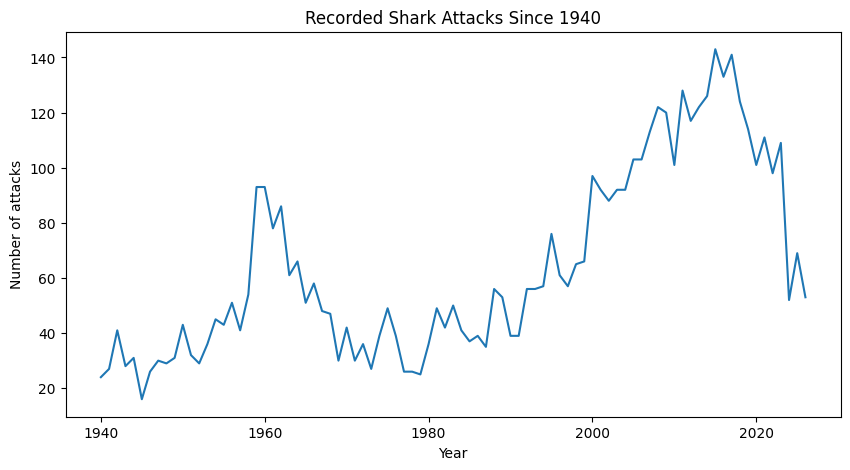

Average attacks per year in the 1940s: 28.3
Average attacks per year in the 2010s: 124.9


**************** Part 4 ****************
Age
NaN    1777
16       80
19       80
17       79
15       76
18       74
20       73
17       72
20       67
25       66
15       65
22       64
21       64
18       63
24       58
19       57
14       57
16       56
21       56
14       52
24       52
26       51
22       51
12       49
25       48
13       48
28       47
29       47
13       46
26       44
Name: count, dtype: int64
['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s']
count       3645.0
mean     28.6

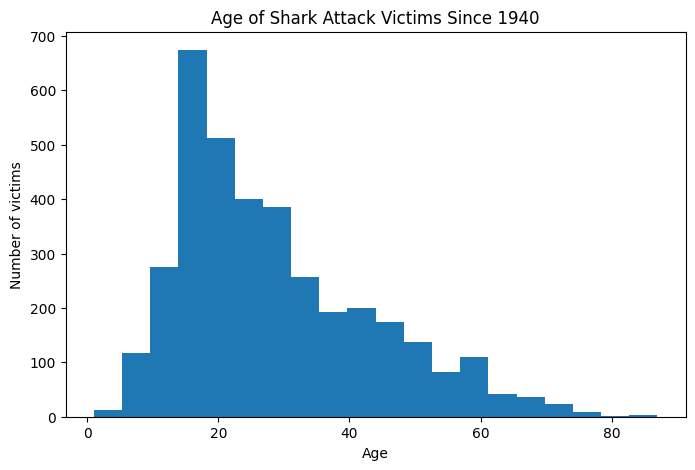



**************** Part 5 ****************
Sex
M        4384
F         730
NaN       451
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64
Sex_clean
M       4393
F        732
<NA>     456
Name: count, dtype: Int64
Proportion male: 0.8571707317073171
Percent male: 85.71707317073171


**************** Part 6 ****************
Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64
Proportion unprovoked: 0.7459236695932628


In [26]:
# Q2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Open Excel file
print("**************** Part 1 ****************")
sharks = pd.read_excel("./data/GSAF5.xls")

print(sharks.shape)
print(sharks.columns)


# 2. Drop columns that do not contain useful data
print("\n\n**************** Part 2 ****************")

print(sharks.notna().sum())

# These are essentially empty unnamed columns
sharks = sharks.drop(columns=["Unnamed: 21", "Unnamed: 22"])


# 3. Clean Year
print("\n\n**************** Part 3 ****************")

# Inspect Year before clean
print(sharks["Year"].describe())
print(sharks["Year"].value_counts(dropna=False).sort_index().head(20))

# Create a numeric cleaned version
sharks["Year_clean"] = pd.to_numeric(
    sharks["Year"],
    errors="coerce"
)

# 0 is being used for cases where the exact year is unknown, so it will treat it as missing
sharks["Year_clean"] = sharks["Year_clean"].replace(0, np.nan)

print(sharks["Year_clean"].describe())


# Filter to attacks since 1940
sharks_recent = sharks[
    sharks["Year_clean"] >= 1940
].copy()

print("Number of attacks since 1940:", len(sharks_recent))


# Count attacks by year
attacks_by_year = (
    sharks_recent
    .groupby("Year_clean")
    .size()
)

# Plot attacks over time
plt.figure(figsize=(10, 5))
plt.plot(attacks_by_year.index, attacks_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.title("Recorded Shark Attacks Since 1940")
plt.show()

# Some summaries that help describe the trend
print(
    "Average attacks per year in the 1940s:",
    attacks_by_year.loc[1940:1949].mean()
)

print(
    "Average attacks per year in the 2010s:",
    attacks_by_year.loc[2010:2019].mean()
)


# 4. Clean Age and make a histogram
print("\n\n**************** Part 4 ****************")

# Inspect Age before cleaning
print(sharks_recent["Age"].value_counts(dropna=False).head(30))
print(sharks_recent["Age"].unique()[:100])

# Remove surrounding whitespace and convert valid numeric ages to numeric values. This will convert invalid ages to NaN
sharks_recent["Age_clean"] = pd.to_numeric(
    sharks_recent["Age"]
    .astype("string")
    .str.strip(),
    errors="coerce"
)

# describe cleaned Age va and count missing values
print(sharks_recent["Age_clean"].describe())
print(
    "Missing ages after cleaning:",
    sharks_recent["Age_clean"].isna().sum()
)

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(
    sharks_recent["Age_clean"].dropna(),
    bins=20
)
plt.xlabel("Age")
plt.ylabel("Number of victims")
plt.title("Age of Shark Attack Victims Since 1940")
plt.show()


# 5. Proportion of victims who are male
print("\n\n**************** Part 5 ****************")

# Inspect Sex
print(sharks_recent["Sex"].value_counts(dropna=False))

# Standardize caps and whitespace
sex = (
    sharks_recent["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Only M and F are unambiguous values
sharks_recent["Sex_clean"] = sex.where(
    sex.isin(["M", "F"])
)

print(sharks_recent["Sex_clean"].value_counts(dropna=False))

# Calculate proportion male among victims with known M/F sex
male_proportion = (
    sharks_recent.loc[
        sharks_recent["Sex_clean"].notna(),
        "Sex_clean"
    ]
    .eq("M")
    .mean()
)

print("Proportion male:", male_proportion)
print("Percent male:", male_proportion * 100)


# 6. Clean Type
print("\n\n**************** Part 6 ****************")

# Inspect Type first
print(sharks_recent["Type"].value_counts(dropna=False))

type_text = (
    sharks_recent["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Keep Provoked and Unprovoked.
# Everything else is classified as Unknown.
sharks_recent["Type_clean"] = (
    type_text
    .map({
        "provoked": "Provoked",
        "unprovoked": "Unprovoked"
    })
    .fillna("Unknown")
)

print(sharks_recent["Type_clean"].value_counts())

unprovoked_proportion = (
    sharks_recent["Type_clean"]
    .eq("Unprovoked")
    .mean()
)

print("Proportion unprovoked:", unprovoked_proportion)
print("Percent unprovoked:", unprovoked_proportion * 100)

# Explanations

## Q1.1

The `Price` variable was initially an object instead of a numeric variable, and I saw that for prices greater than 999, there were commas, which prevented them from being recognized as numbers. I removed the commas and converted the variables to be numeric, and I saw that there were zero missing values before cleaning and zero missing values afterwards too. 

## Q1.2

When I inspected the `subject_injury` variable, I found that its only non-missing values were "yes" and "no". I standardized the variable by removing white space and restricting the valid observations to just those two categories. Anything outside of "yes" or "no" was considered missing.

The biggest issue was with missing data. There were 9,848 missing observations out of the 12,925 total, which meant that around 76.2% of the values were missing. This is extremely concerning because over three-fourths of the observations don't report if the subject was injured or not. This could lead to severe bias and unreliability with the data we have.

The cross-tabulation shows that missing injury information isn't evenly distributed across force types. For example, Less Lethal and Maximal Restraint Technique have missing injury information for all observations, while Chemical Irritant also has a very high missing rate. In contrast, Gun Point Display and Police K9 Bite have much lower proportions of missing injury data. The pattern suggests that the missingness could be related to the type of force, rather than it occurring generally across all observations. 

## Q2.1

The original dataset contained 7,117 observations in 23 columns. I examined how many non-missing observations there were in each column, and I found that unnamed 21 and unnamed 22 contained 1 and 2 non-missing values, respectively, and didn't even represent anything meaningful. As a result, I dropped those columns, but kept all the other columns, even if some of them contained some missing values. 

## Q2.3

I inspected the `Year` variable and found values ranging from 0 to 2026. The value 0 does not represent a meaningful calendar year and is used when the precise year is probably not available, so I converted the variable to numeric and replaced 0 with missing. After that, the years ranged from 5 to 2026. The very early years did represent very historical observations, so I didn't remove them, but I filtered the data to be observations from 1940 onwards, which left 5,581 attacks to use during the analysis. 

The plot shows that the number of shark attacks generally increased over time, but it's not a very constant pattern, and there is some variation. There are around 28.3 attacks per year in the 1940s, compared to around 124.9 attacks per year in the 2010s. 

## Q2.4

The Age variable has a mix of proper numeric ages but also nonnumeric values. I removed whitespace and marked entries without a single numerical age as missing. After this cleaning, 3,645 observations had numeric ages and 1,936 were missing.

The histogram shows shark attack victims mainly happens with younger people, especially teenagers and young adults. The largest concentration occurs around the mid-to-late teenage years, and the frequency generally goes down as age goes up. It is right-skewed, with a longer tail for older ages. The median age is 25 years, while the mean is approximately 28.6 years.

## Q2.5

The `Sex` variable contained mainly M and F, but also included inconsistent formatting and some ambiguous values. I removed whitespace, standardized capitalization, retained M and F observations, and treated anything else as missing. After cleaning, there were 4,393 male victims and 732 female victims, with 456 observations for which sex could not be confidently classified as either. Among victims whose sex was known as male or female, approximately 85.7% were male.

## Q2.6

I standardized capitalization and whitespace in `Type`, combined all versions of provoked and unprovoked attacks, and classified every other value as "Unknown". Approximately 74.6% of attacks since 1940 were unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]